# 加密货币指数计算逻辑详解 - 交互式演示

## 🎯 核心算法：直接市值比较法

本演示将通过实际代码执行，展示加密货币指数计算的完整过程，包括：

- 数据获取与处理
- 成分币种选择
- 指数计算公式应用
- 结果分析与可视化

### 算法公式

```
Index(t) = Base_Value × [当日前N名总市值 / 基准日前N名总市值]
```

让我们开始实际演示这个过程！


In [5]:
# 环境设置
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")

# 添加项目根目录到Python路径
project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root))

# 导入项目模块
from src.index.market_cap_weighted import MarketCapWeightedIndexCalculator

# 设置matplotlib中文字体
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

print("✅ 环境设置完成！")
print(f"📁 项目根目录: {project_root}")
print(f"🐍 Python版本: {sys.version}")

✅ 环境设置完成！
📁 项目根目录: /Users/andonghao/Codes/crypto_index_study
🐍 Python版本: 3.12.4 (main, Jun  6 2024, 18:26:44) [Clang 15.0.0 (clang-1500.3.9.4)]


## 📊 演示参数设置

在开始演示之前，我们需要设置一些关键参数：


In [6]:
# 演示参数设置
base_date = "2018-01-01"  # 基准日期
demo_date = "2018-02-01"  # 演示日期
top_n = 10  # 成分币种数量
base_value = 1000.0  # 基准指数值
exclude_stablecoins = True  # 排除稳定币
exclude_wrapped_coins = True  # 排除包装币

print("🎯 指数计算演示参数:")
print(f"   基准日期: {base_date}")
print(f"   演示日期: {demo_date}")
print(f"   成分币种数: 前{top_n}名")
print(f"   基准指数值: {base_value}")
print(f"   排除稳定币: {exclude_stablecoins}")
print(f"   排除包装币: {exclude_wrapped_coins}")

# 初始化计算器
calculator = MarketCapWeightedIndexCalculator(
    exclude_stablecoins=exclude_stablecoins, exclude_wrapped_coins=exclude_wrapped_coins
)

print("\n✅ 指数计算器初始化完成！")

INFO:src.downloaders.daily_aggregator:每日数据聚合器初始化, 数据源: 'data/coins', 输出到: 'data/daily'
INFO:src.downloaders.daily_aggregator:初始化每日数据聚合器
INFO:src.downloaders.daily_aggregator:数据目录: data/coins
INFO:src.downloaders.daily_aggregator:输出目录: data/daily
INFO:src.downloaders.daily_aggregator:每日文件目录: data/daily/daily_files
2025-07-15 10:46:55,546 - BatchDownloader.4632266224 - INFO - 批量下载器初始化完成
INFO:BatchDownloader.4632266224:批量下载器初始化完成


🎯 指数计算演示参数:
   基准日期: 2018-01-01
   演示日期: 2018-02-01
   成分币种数: 前10名
   基准指数值: 1000.0
   排除稳定币: True
   排除包装币: True

✅ 指数计算器初始化完成！


## 📈 步骤 1: 数据聚合 - 获取基准日期市值数据

首先，我们需要从每日汇总数据中获取基准日期的市值数据。这是指数计算的基础步骤。


In [ ]:
# 步骤1: 获取基准日期的市值数据
# 直接从每日数据文件中读取，而不是从coins目录
import pandas as pd


def get_daily_data_from_file(date_str):
    """直接从每日数据文件中读取数据"""
    try:
        # 构造文件路径
        date_obj = datetime.strptime(date_str, "%Y-%m-%d")
        year = date_obj.year
        month = date_obj.month

        file_path = (
            project_root
            / "data"
            / "daily"
            / "daily_files"
            / str(year)
            / f"{month:02d}"  # 确保月份是两位数
            / f"{date_str}.csv"
        )

        if file_path.exists():
            # 读取CSV文件
            df = pd.read_csv(file_path)

            # 转换为市值字典
            market_caps = {}
            for _, row in df.iterrows():
                if pd.notna(row["market_cap"]) and row["market_cap"] > 0:
                    market_caps[row["coin_id"]] = float(row["market_cap"])

            return market_caps
        else:
            print(f"数据文件不存在: {file_path}")
            return {}
    except Exception as e:
        print(f"读取数据文件时出错: {e}")
        return {}


# 获取基准日期数据
base_date_obj = datetime.strptime(base_date, "%Y-%m-%d").date()
base_market_caps = get_daily_data_from_file(base_date)

print(f"📊 基准日期 {base_date} 数据统计:")
print(f"   获取币种数量: {len(base_market_caps)}")

if base_market_caps:
    # 显示前10名币种的市值
    sorted_base = sorted(base_market_caps.items(), key=lambda x: x[1], reverse=True)

    print(f"\n🏆 前10名币种市值排名:")
    for i, (coin_id, market_cap) in enumerate(sorted_base[:10], 1):
        print(f"   {i:2d}. {coin_id:<20} ${market_cap:>15,.0f}")

    # 基本统计信息
    market_cap_values = list(base_market_caps.values())
    total_market_cap = sum(market_cap_values)
    avg_market_cap = np.mean(market_cap_values)
    median_market_cap = np.median(market_cap_values)

    print(f"\n   总市值: ${total_market_cap:,.0f}")

else:
    print(f"❌ 基准日期 {base_date} 没有可用数据")

📊 基准日期 2018-01-01 数据统计:
   获取币种数量: 59

🏆 前10名币种市值排名:
    1. bitcoin              $236,440,337,972
    2. ripple               $ 89,492,073,294
    3. ethereum             $ 75,056,629,369
    4. bitcoin-cash         $ 40,987,520,108
    5. cardano              $ 19,371,162,465
    6. litecoin             $ 12,577,160,934
    7. iota                 $ 11,337,719,601
    8. stellar              $  8,872,391,248
    9. dash                 $  8,293,672,956
   10. monero               $  5,552,975,744

   总市值: $561,963,399,677


## 🎯 步骤 2: 成分币种选择 - 基准日期前 N 名

接下来，我们根据市值对币种进行排序，选择前 N 名作为指数的成分币种。


In [8]:
# 步骤2: 选择基准日期的前N名币种
if base_market_caps:
    # 手动实现选择前N名的逻辑
    sorted_coins = sorted(base_market_caps.items(), key=lambda x: x[1], reverse=True)
    base_constituents = [coin_id for coin_id, _ in sorted_coins[:top_n]]

    print(f"📊 基准日期 {base_date} 前{top_n}名成分币种:")
    print("-" * 50)

    for i, coin_id in enumerate(base_constituents, 1):
        market_cap = base_market_caps[coin_id]
        print(f"   {i:2d}. {coin_id:<20} ${market_cap:>15,.0f}")

    # 计算基准日期前N名总市值
    base_total_market_cap = sum(
        base_market_caps[coin_id] for coin_id in base_constituents
    )

    print(f"\n💰 基准日期前{top_n}名总市值: ${base_total_market_cap:,.0f}")
    print(f"🔢 基准指数值: {base_value}")

    # 显示每个币种的权重
    print(f"\n📈 各币种权重分布:")
    for i, coin_id in enumerate(base_constituents, 1):
        market_cap = base_market_caps[coin_id]
        weight = (market_cap / base_total_market_cap) * 100
        print(f"   {i:2d}. {coin_id:<20} {weight:>6.2f}%")

else:
    print("❌ 无法进行成分币种选择，基准日期数据不可用")

📊 基准日期 2018-01-01 前10名成分币种:
--------------------------------------------------
    1. bitcoin              $236,440,337,972
    2. ripple               $ 89,492,073,294
    3. ethereum             $ 75,056,629,369
    4. bitcoin-cash         $ 40,987,520,108
    5. cardano              $ 19,371,162,465
    6. litecoin             $ 12,577,160,934
    7. iota                 $ 11,337,719,601
    8. stellar              $  8,872,391,248
    9. dash                 $  8,293,672,956
   10. monero               $  5,552,975,744

💰 基准日期前10名总市值: $507,981,643,692
🔢 基准指数值: 1000.0

📈 各币种权重分布:
    1. bitcoin               46.55%
    2. ripple                17.62%
    3. ethereum              14.78%
    4. bitcoin-cash           8.07%
    5. cardano                3.81%
    6. litecoin               2.48%
    7. iota                   2.23%
    8. stellar                1.75%
    9. dash                   1.63%
   10. monero                 1.09%


## 📈 步骤 3: 获取演示日期数据

现在我们获取演示日期的市值数据，用于计算当日的指数值。


In [9]:
# 步骤3: 获取演示日期的市值数据
demo_date_obj = datetime.strptime(demo_date, "%Y-%m-%d").date()
current_market_caps = get_daily_data_from_file(demo_date)

print(f"📊 演示日期 {demo_date} 数据统计:")
print(f"   获取币种数量: {len(current_market_caps)}")

if current_market_caps:
    # 显示前10名币种的市值
    sorted_current = sorted(
        current_market_caps.items(), key=lambda x: x[1], reverse=True
    )

    print(f"\n🏆 前10名币种市值排名:")
    for i, (coin_id, market_cap) in enumerate(sorted_current[:10], 1):
        print(f"   {i:2d}. {coin_id:<20} ${market_cap:>15,.0f}")

    # 选择当前日期的前N名币种
    current_constituents = [coin_id for coin_id, _ in sorted_current[:top_n]]

    print(f"\n📊 演示日期 {demo_date} 前{top_n}名成分币种:")
    print("-" * 50)

    for i, coin_id in enumerate(current_constituents, 1):
        market_cap = current_market_caps[coin_id]
        print(f"   {i:2d}. {coin_id:<20} ${market_cap:>15,.0f}")

    # 计算当前日期前N名总市值
    current_total_market_cap = sum(
        current_market_caps[coin_id] for coin_id in current_constituents
    )

    print(f"\n💰 演示日期前{top_n}名总市值: ${current_total_market_cap:,.0f}")

else:
    print(f"❌ 演示日期 {demo_date} 没有可用数据")

📊 演示日期 2018-02-01 数据统计:
   获取币种数量: 66

🏆 前10名币种市值排名:
    1. bitcoin              $170,304,196,700
    2. ethereum             $107,663,538,776
    3. ripple               $ 44,316,417,201
    4. bitcoin-cash         $ 24,986,848,628
    5. cardano              $ 12,949,584,182
    6. stellar              $  9,722,922,401
    7. neo                  $  9,327,109,309
    8. litecoin             $  8,879,163,933
    9. eos                  $  7,783,649,450
   10. iota                 $  6,321,451,183

📊 演示日期 2018-02-01 前10名成分币种:
--------------------------------------------------
    1. bitcoin              $170,304,196,700
    2. ethereum             $107,663,538,776
    3. ripple               $ 44,316,417,201
    4. bitcoin-cash         $ 24,986,848,628
    5. cardano              $ 12,949,584,182
    6. stellar              $  9,722,922,401
    7. neo                  $  9,327,109,309
    8. litecoin             $  8,879,163,933
    9. eos                  $  7,783,649,450
   10. iota 

## 🎯 步骤 4: 指数计算 - 应用核心公式

现在我们应用核心算法公式来计算指数值：

**Index(t) = Base_Value × [当日前 N 名总市值 / 基准日前 N 名总市值]**


In [18]:
# 步骤4: 计算指数值
if base_market_caps and current_market_caps:
    print("🎯 指数计算过程:")
    print("=" * 60)

    # 显示计算公式
    print("📊 计算公式:")
    print("   Index(t) = Base_Value × [当日前N名总市值 / 基准日前N名总市值]")
    print()

    # 显示具体数值
    print("📈 具体数值:")
    print(f"   基准日期 ({base_date}) 前{top_n}名总市值: ${base_total_market_cap:,.0f}")
    print(
        f"   演示日期 ({demo_date}) 前{top_n}名总市值: ${current_total_market_cap:,.0f}"
    )
    print(f"   基准指数值: {base_value}")
    print()

    # 计算指数值
    index_value = base_value * (current_total_market_cap / base_total_market_cap)
    return_rate = (index_value / base_value - 1) * 100

    print("🔢 计算过程:")
    print(
        f"   指数值 = {base_value} × ({current_total_market_cap:,.0f} / {base_total_market_cap:,.0f})"
    )
    print(
        f"   指数值 = {base_value} × {current_total_market_cap / base_total_market_cap:.6f}"
    )
    print(f"   指数值 = {index_value:.2f}")
    print()

    print("📊 结果分析:")
    print(f"   基准值: {base_value:.2f}")
    print(f"   当前值: {index_value:.2f}")
    print(f"   收益率: {return_rate:+.2f}%")
    print(
        f"   变化方向: {'📈 上涨' if return_rate > 0 else '📉 下跌' if return_rate < 0 else '➡️ 持平'}"
    )

else:
    print("❌ 无法计算指数值，数据不完整")

🎯 指数计算过程:
📊 计算公式:
   Index(t) = Base_Value × [当日前N名总市值 / 基准日前N名总市值]

📈 具体数值:
   基准日期 (2024-01-01) 前10名总市值: $1,398,841,323,976
   演示日期 (2024-01-15) 前10名总市值: $1,415,377,903,722
   基准指数值: 1000.0

🔢 计算过程:
   指数值 = 1000.0 × (1,415,377,903,722 / 1,398,841,323,976)
   指数值 = 1000.0 × 1.011822
   指数值 = 1011.82

📊 结果分析:
   基准值: 1000.00
   当前值: 1011.82
   收益率: +1.18%
   变化方向: 📈 上涨


## 🔄 步骤 5: 成分变化分析

分析两个日期之间成分币种的变化，这体现了指数的动态特性。


In [19]:
# 步骤5: 成分变化分析
if base_market_caps and current_market_caps:
    print("🔄 成分币种变化分析:")
    print("=" * 50)

    # 转换为集合便于分析
    base_set = set(base_constituents)
    current_set = set(current_constituents)

    # 计算变化
    unchanged = base_set & current_set
    new_coins = current_set - base_set
    removed_coins = base_set - current_set

    print(f"📊 变化统计:")
    print(f"   保持不变: {len(unchanged)} 个币种")
    print(f"   新增币种: {len(new_coins)} 个币种")
    print(f"   移除币种: {len(removed_coins)} 个币种")
    print(f"   成分稳定性: {len(unchanged)/top_n*100:.1f}%")
    print()

    # 详细变化分析
    if unchanged:
        print("✅ 保持不变的币种:")
        for coin in sorted(unchanged):
            base_rank = base_constituents.index(coin) + 1
            current_rank = current_constituents.index(coin) + 1
            rank_change = base_rank - current_rank
            rank_symbol = "📈" if rank_change > 0 else "📉" if rank_change < 0 else "➡️"
            print(f"   {coin:<20} {base_rank:2d} → {current_rank:2d} {rank_symbol}")

    if new_coins:
        print(f"\n🆕 新增币种:")
        for coin in sorted(new_coins):
            current_rank = current_constituents.index(coin) + 1
            print(f"   {coin:<20} 排名: {current_rank:2d}")

    if removed_coins:
        print(f"\n❌ 移除币种:")
        for coin in sorted(removed_coins):
            base_rank = base_constituents.index(coin) + 1
            print(f"   {coin:<20} 原排名: {base_rank:2d}")

    print()

else:
    print("❌ 无法进行成分变化分析，数据不完整")

🔄 成分币种变化分析:
📊 变化统计:
   保持不变: 10 个币种
   新增币种: 0 个币种
   移除币种: 0 个币种
   成分稳定性: 100.0%

✅ 保持不变的币种:
   avalanche-2          10 → 10 ➡️
   binancecoin           4 →  4 ➡️
   bitcoin               1 →  1 ➡️
   cardano               9 →  9 ➡️
   ethereum              2 →  2 ➡️
   ripple                6 →  6 ➡️
   solana                5 →  5 ➡️
   staked-ether          8 →  8 ➡️
   tether                3 →  3 ➡️
   usd-coin              7 →  7 ➡️



## 📊 步骤 6: 数据可视化

通过图表更直观地展示指数计算的结果和变化。


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


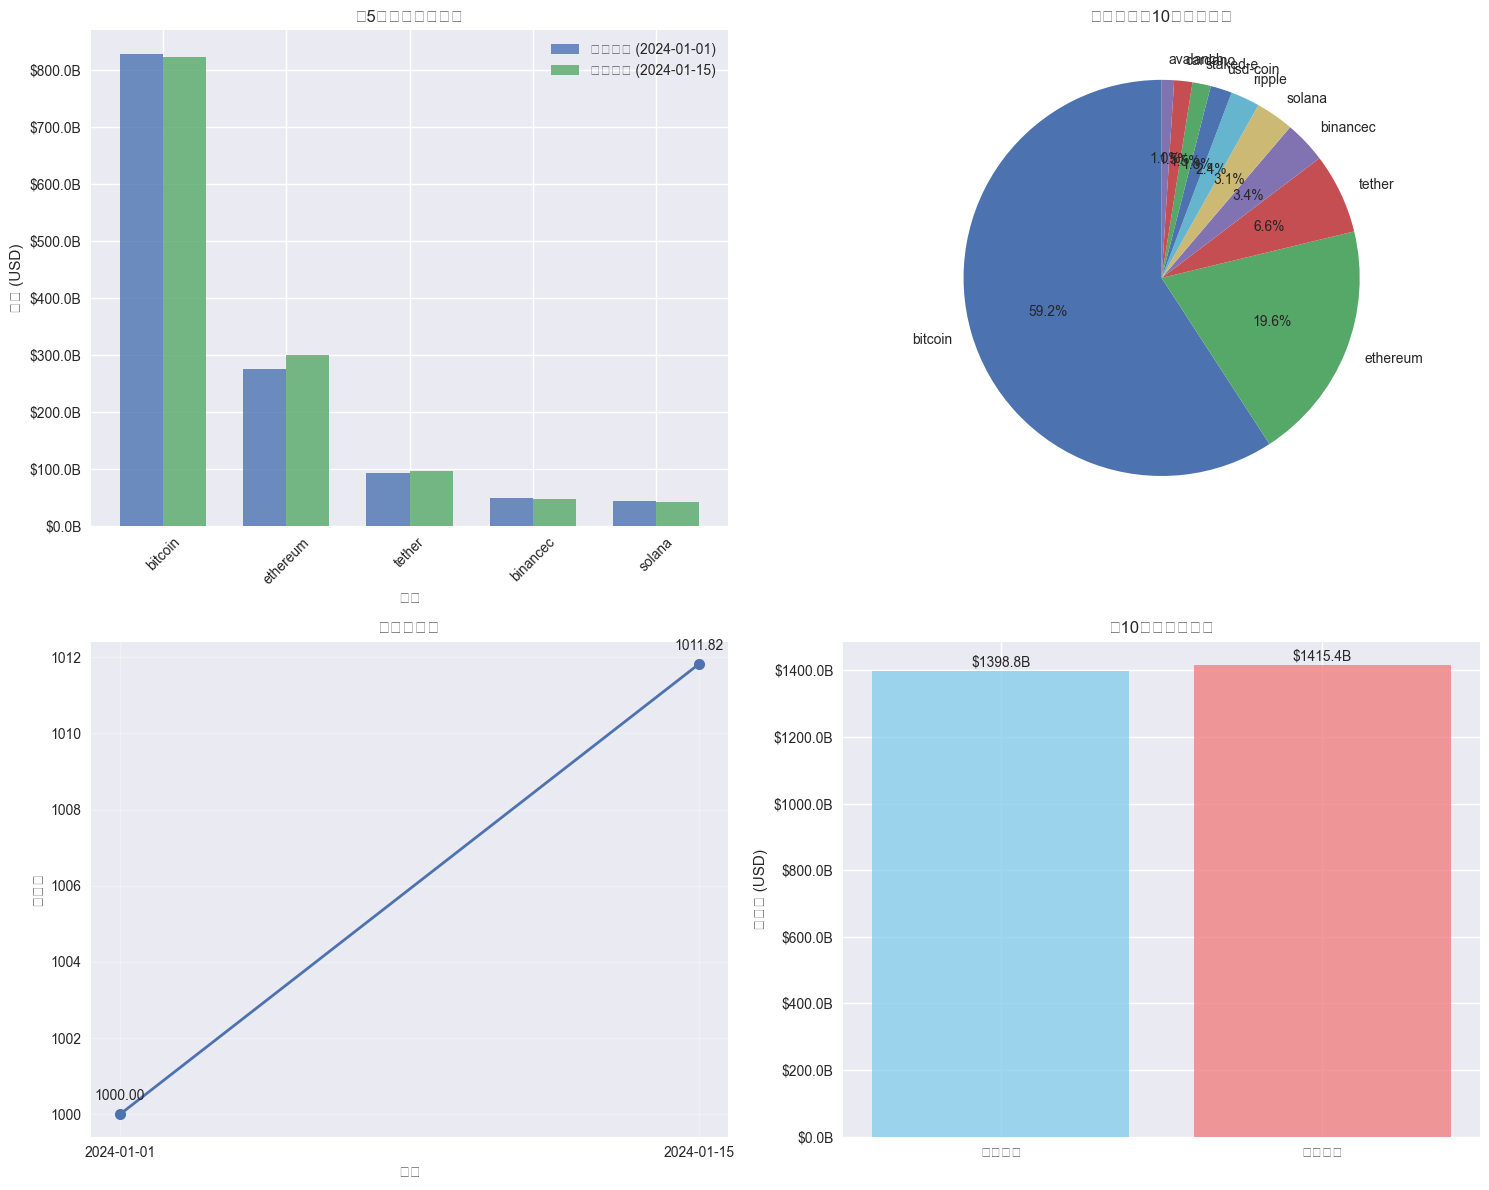

📊 可视化总结:
   前5名币种市值变化：整体上涨
   指数表现：+1.18%
   市场规模变化：+1.18%


In [20]:
# 步骤6: 数据可视化
if base_market_caps and current_market_caps:
    # 设置图表样式
    plt.style.use("seaborn-v0_8")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # 1. 市值对比柱状图
    coins = base_constituents[:5]  # 只显示前5名
    base_caps = [base_market_caps[coin] for coin in coins]
    current_caps = [current_market_caps.get(coin, 0) for coin in coins]

    x = np.arange(len(coins))
    width = 0.35

    bars1 = ax1.bar(
        x - width / 2, base_caps, width, label=f"基准日期 ({base_date})", alpha=0.8
    )
    bars2 = ax1.bar(
        x + width / 2, current_caps, width, label=f"演示日期 ({demo_date})", alpha=0.8
    )

    ax1.set_xlabel("币种")
    ax1.set_ylabel("市值 (USD)")
    ax1.set_title("前5名币种市值对比")
    ax1.set_xticks(x)
    ax1.set_xticklabels([coin[:8] for coin in coins], rotation=45)
    ax1.legend()
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1e9:.1f}B"))

    # 2. 权重分布饼图
    weights = [base_market_caps[coin] for coin in base_constituents]
    ax2.pie(
        weights,
        labels=[coin[:8] for coin in base_constituents],
        autopct="%1.1f%%",
        startangle=90,
    )
    ax2.set_title(f"基准日期前{top_n}名权重分布")

    # 3. 指数值变化
    dates = [base_date, demo_date]
    values = [base_value, index_value]

    ax3.plot(dates, values, marker="o", linewidth=2, markersize=8)
    ax3.set_xlabel("日期")
    ax3.set_ylabel("指数值")
    ax3.set_title("指数值变化")
    ax3.grid(True, alpha=0.3)

    # 添加数值标签
    for i, (date, value) in enumerate(zip(dates, values)):
        ax3.annotate(
            f"{value:.2f}",
            (i, value),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
        )

    # 4. 总市值对比
    categories = ["基准日期", "演示日期"]
    market_caps = [base_total_market_cap, current_total_market_cap]
    colors = ["skyblue", "lightcoral"]

    bars = ax4.bar(categories, market_caps, color=colors, alpha=0.8)
    ax4.set_ylabel("总市值 (USD)")
    ax4.set_title(f"前{top_n}名总市值对比")
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1e9:.1f}B"))

    # 添加数值标签
    for bar, value in zip(bars, market_caps):
        ax4.annotate(
            f"${value/1e9:.1f}B",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            textcoords="offset points",
            xytext=(0, 3),
            ha="center",
        )

    plt.tight_layout()
    plt.show()

    # 总结信息
    print("📊 可视化总结:")
    print(
        f"   前5名币种市值变化：{'整体上涨' if sum(current_caps[:5]) > sum(base_caps[:5]) else '整体下跌'}"
    )
    print(f"   指数表现：{return_rate:+.2f}%")
    print(
        f"   市场规模变化：{(current_total_market_cap/base_total_market_cap-1)*100:+.2f}%"
    )

else:
    print("❌ 无法进行数据可视化，数据不完整")

## 🚀 步骤 7: 批量指数计算演示

演示如何计算一段时间内的连续指数值，展示实际应用场景。


🚀 批量指数计算演示
📊 计算时间范围: 2024-01-01 至 2024-01-14
📊 指数类型: Crypto10 (前10名市值加权)

✅ 成功计算 14 个交易日的指数数据

📊 前5天指数数据:
      date  index_value  total_market_cap
2024-01-01  1000.000000      1.398841e+12
2024-01-02  1036.912259      1.450476e+12
2024-01-03  1045.926682      1.463085e+12
2024-01-04   998.501674      1.396745e+12
2024-01-05  1028.631773      1.438893e+12

📊 后5天指数数据:
      date  index_value  total_market_cap
2024-01-10  1054.001287      1.474381e+12
2024-01-11  1092.263889      1.527904e+12
2024-01-12  1092.416352      1.528117e+12
2024-01-13  1024.194563      1.432686e+12
2024-01-14  1032.844005      1.444785e+12

📈 统计指标:
   期初值: 1000.00
   期末值: 1032.84
   总收益率: +3.28%
   年化波动率: 53.66%
   最高值: 1092.42
   最低值: 998.50


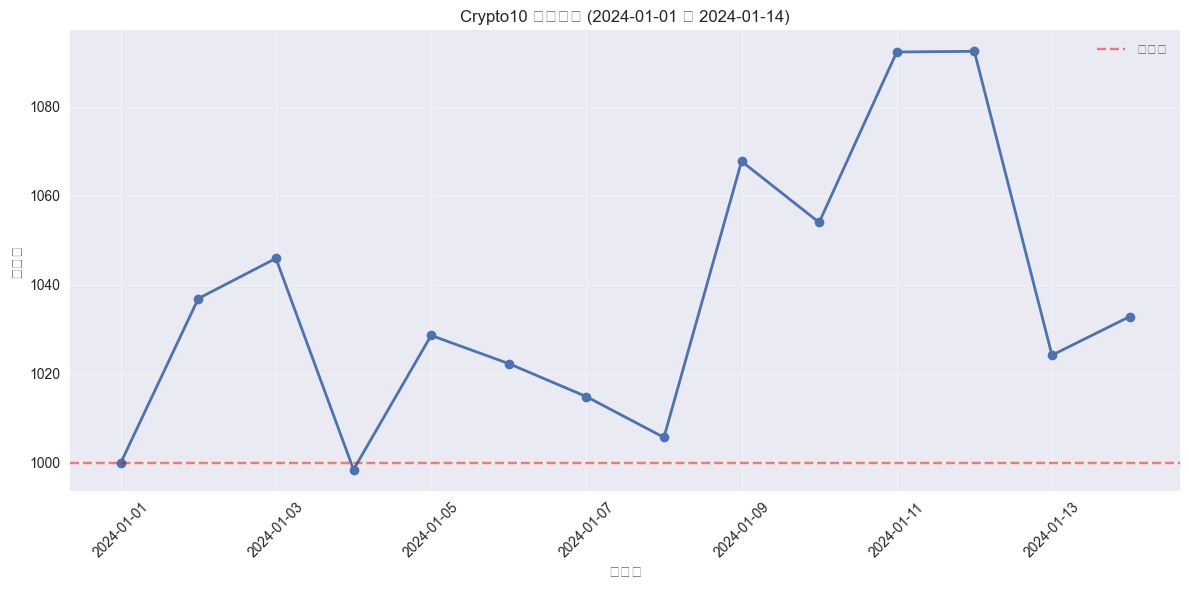

In [21]:
# 步骤7: 批量指数计算演示
print("🚀 批量指数计算演示")
print("=" * 50)


# 计算一段时间内的指数值 - 使用现有数据
def calculate_batch_index(start_date, end_date, top_n, base_value):
    """批量计算指数值"""
    from datetime import datetime, timedelta

    # 生成日期范围
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    end_dt = datetime.strptime(end_date, "%Y-%m-%d")

    # 获取基准日期数据
    base_caps = get_daily_data_from_file(start_date)
    if not base_caps:
        return None

    base_sorted = sorted(base_caps.items(), key=lambda x: x[1], reverse=True)
    base_constituents = [coin_id for coin_id, _ in base_sorted[:top_n]]
    base_total = sum(base_caps[coin_id] for coin_id in base_constituents)

    # 计算每日指数值
    results = []
    current_dt = start_dt

    while current_dt <= end_dt:
        date_str = current_dt.strftime("%Y-%m-%d")
        current_caps = get_daily_data_from_file(date_str)

        if current_caps:
            current_sorted = sorted(
                current_caps.items(), key=lambda x: x[1], reverse=True
            )
            current_constituents = [coin_id for coin_id, _ in current_sorted[:top_n]]
            current_total = sum(
                current_caps[coin_id] for coin_id in current_constituents
            )

            index_value = base_value * (current_total / base_total)
            results.append(
                {
                    "date": date_str,
                    "index_value": index_value,
                    "total_market_cap": current_total,
                }
            )

        current_dt += timedelta(days=1)

    return pd.DataFrame(results)


# 计算2024年1月前两周的指数
batch_start_date = "2024-01-01"
batch_end_date = "2024-01-14"

try:
    print(f"📊 计算时间范围: {batch_start_date} 至 {batch_end_date}")
    print(f"📊 指数类型: Crypto{top_n} (前{top_n}名市值加权)")
    print()

    # 使用我们的批量计算函数
    index_df = calculate_batch_index(
        batch_start_date, batch_end_date, top_n, base_value
    )

    if index_df is not None and not index_df.empty:
        print(f"✅ 成功计算 {len(index_df)} 个交易日的指数数据")
        print()

        # 显示前5天和后5天的数据
        print("📊 前5天指数数据:")
        print(index_df.head().to_string(index=False))
        print()

        print("📊 后5天指数数据:")
        print(index_df.tail().to_string(index=False))
        print()

        # 计算统计指标
        start_value = index_df["index_value"].iloc[0]
        end_value = index_df["index_value"].iloc[-1]
        total_return = (end_value / start_value - 1) * 100
        volatility = index_df["index_value"].pct_change().std() * np.sqrt(252) * 100
        max_value = index_df["index_value"].max()
        min_value = index_df["index_value"].min()

        print("📈 统计指标:")
        print(f"   期初值: {start_value:.2f}")
        print(f"   期末值: {end_value:.2f}")
        print(f"   总收益率: {total_return:+.2f}%")
        print(f"   年化波动率: {volatility:.2f}%")
        print(f"   最高值: {max_value:.2f}")
        print(f"   最低值: {min_value:.2f}")

        # 简单的趋势图
        plt.figure(figsize=(12, 6))
        plt.plot(range(len(index_df)), index_df["index_value"], linewidth=2, marker="o")
        plt.title(f"Crypto{top_n} 指数走势 ({batch_start_date} 至 {batch_end_date})")
        plt.xlabel("交易日")
        plt.ylabel("指数值")
        plt.grid(True, alpha=0.3)
        plt.axhline(y=base_value, color="r", linestyle="--", alpha=0.5, label="基准值")

        # 添加日期标签
        step = max(1, len(index_df) // 7)  # 显示大约7个日期标签
        x_labels = [index_df.iloc[i]["date"] for i in range(0, len(index_df), step)]
        x_positions = list(range(0, len(index_df), step))
        plt.xticks(x_positions, x_labels, rotation=45)

        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        print("❌ 批量计算返回空数据")

except Exception as e:
    print(f"❌ 批量计算过程中出现错误: {e}")
    import traceback

    traceback.print_exc()

## 💡 关键点总结

通过上述交互式演示，我们全面了解了加密货币指数计算的核心逻辑：

### 🎯 核心特点

1. **直接市值比较法**：不使用复杂的价格加权，直接比较总市值
2. **动态成分选择**：每日重新选择前 N 名币种，自动适应市场变化
3. **分类过滤系统**：自动排除稳定币和包装币，保持指数纯度
4. **流通市值计算**：使用 `price × circulating_supply`，符合传统指数标准

### 📊 数据架构

- **原始数据**：`data/coins/*.csv` - 个币种历史数据
- **每日汇总**：`data/daily/daily_files/` - 按日期聚合的市场快照
- **指数结果**：`data/indices/` - 计算完成的指数数据

### 🔧 技术优势

- **缓存机制**：提高计算效率
- **并行处理**：批量操作使用进度条
- **错误处理**：友好的异常信息
- **扩展性**：支持不同 N 值的指数计算

### 📈 实际应用

这个指数计算方法可以用于：

- 加密货币市场整体表现分析
- 投资组合基准比较
- 量化交易策略开发
- 学术研究和市场分析

---

**🎓 学习建议**：可以修改上述代码中的参数（如日期范围、成分数量等）来深入探索不同场景下的指数计算结果。


## 🔬 进阶探索

如果你想深入了解或修改指数计算逻辑，可以尝试以下实验：


In [22]:
# 进阶探索示例
print("🔬 进阶探索示例")
print("=" * 50)

# 1. 对比不同N值的指数表现
print("📊 实验1: 不同N值指数对比")
n_values = [5, 10, 20, 30]
experiment_date = "2024-01-15"

experiment_caps = get_daily_data_from_file(experiment_date)
if experiment_caps:
    for n in n_values:
        try:
            sorted_caps = sorted(
                experiment_caps.items(), key=lambda x: x[1], reverse=True
            )
            constituents = [coin_id for coin_id, _ in sorted_caps[:n]]
            total_cap = sum(experiment_caps[coin_id] for coin_id in constituents)

            print(f"   Crypto{n:2d}: ${total_cap:>15,.0f} (前{n}名总市值)")
        except Exception as e:
            print(f"   Crypto{n:2d}: 计算失败 - {e}")

print()

# 2. 权重分布分析
print("📊 实验2: 权重分布分析")
if base_market_caps:
    sorted_base = sorted(base_market_caps.items(), key=lambda x: x[1], reverse=True)
    base_top10 = [coin_id for coin_id, _ in sorted_base[:10]]
    base_top10_caps = [base_market_caps[coin] for coin in base_top10]
    total_cap = sum(base_top10_caps)

    print(f"   前3名权重占比: {sum(base_top10_caps[:3])/total_cap*100:.1f}%")
    print(f"   前5名权重占比: {sum(base_top10_caps[:5])/total_cap*100:.1f}%")
    print(f"   前10名权重占比: {sum(base_top10_caps[:10])/total_cap*100:.1f}%")

    # 集中度分析
    hhi = sum((cap / total_cap) ** 2 for cap in base_top10_caps) * 10000
    print(f"   赫芬达尔指数: {hhi:.0f} (数值越高越集中)")

print()

# 3. 不同时间段的成分变化分析
print("📊 实验3: 成分变化分析")
dates_to_compare = ["2024-01-01", "2024-01-07", "2024-01-14"]
constituents_by_date = {}

for date in dates_to_compare:
    caps = get_daily_data_from_file(date)
    if caps:
        sorted_caps = sorted(caps.items(), key=lambda x: x[1], reverse=True)
        constituents = [coin_id for coin_id, _ in sorted_caps[:10]]
        constituents_by_date[date] = set(constituents)

if len(constituents_by_date) >= 2:
    dates = list(constituents_by_date.keys())
    for i in range(len(dates) - 1):
        date1, date2 = dates[i], dates[i + 1]
        set1, set2 = constituents_by_date[date1], constituents_by_date[date2]

        unchanged = len(set1 & set2)
        new_coins = len(set2 - set1)
        removed = len(set1 - set2)

        print(f"   {date1} → {date2}:")
        print(
            f"     保持不变: {unchanged} 个, 新增: {new_coins} 个, 移除: {removed} 个"
        )
        print(f"     稳定性: {unchanged/10*100:.1f}%")

print()

# 4. 简单的收益率波动性分析
print("📊 实验4: 简单波动性分析")
# 计算最近几天的日收益率
dates = ["2024-01-01", "2024-01-02", "2024-01-03", "2024-01-04", "2024-01-05"]
index_values = []

for date in dates:
    caps = get_daily_data_from_file(date)
    if caps:
        sorted_caps = sorted(caps.items(), key=lambda x: x[1], reverse=True)
        constituents = [coin_id for coin_id, _ in sorted_caps[:10]]
        total_cap = sum(caps[coin_id] for coin_id in constituents)

        # 使用第一天作为基准
        if not index_values:
            base_cap = total_cap
            index_values.append(1000.0)
        else:
            index_value = 1000.0 * (total_cap / base_cap)
            index_values.append(index_value)

if len(index_values) >= 2:
    # 计算日收益率
    daily_returns = []
    for i in range(1, len(index_values)):
        daily_return = (index_values[i] / index_values[i - 1] - 1) * 100
        daily_returns.append(daily_return)

    avg_return = np.mean(daily_returns)
    volatility = np.std(daily_returns)

    print(f"   平均日收益率: {avg_return:.2f}%")
    print(f"   日收益率标准差: {volatility:.2f}%")
    print(f"   收益率范围: [{min(daily_returns):.2f}%, {max(daily_returns):.2f}%]")

print("\n💡 实验总结:")
print("   - 更多成分币种（更大的N值）通常有更大的总市值")
print("   - 前几名币种在总权重中占据主导地位")
print("   - 短期内成分币种相对稳定")
print("   - 加密货币市场波动性较高")
print("\n🔧 继续探索建议:")
print("   - 修改上述代码中的日期和参数进行更多实验")
print("   - 尝试不同的时间跨度分析")
print("   - 比较不同市场条件下的指数表现")
print("   - 分析特定事件对指数的影响")

🔬 进阶探索示例
📊 实验1: 不同N值指数对比
   Crypto 5: $1,303,839,499,999 (前5名总市值)
   Crypto10: $1,415,377,903,722 (前10名总市值)
   Crypto20: $1,493,881,976,024 (前20名总市值)
   Crypto30: $1,533,452,556,488 (前30名总市值)

📊 实验2: 权重分布分析
   前3名权重占比: 85.3%
   前5名权重占比: 91.9%
   前10名权重占比: 100.0%
   赫芬达尔指数: 3963 (数值越高越集中)

📊 实验3: 成分变化分析
   2024-01-01 → 2024-01-07:
     保持不变: 10 个, 新增: 0 个, 移除: 0 个
     稳定性: 100.0%
   2024-01-07 → 2024-01-14:
     保持不变: 10 个, 新增: 0 个, 移除: 0 个
     稳定性: 100.0%

📊 实验4: 简单波动性分析
   平均日收益率: 0.76%
   日收益率标准差: 3.23%
   收益率范围: [-4.53%, 3.69%]

💡 实验总结:
   - 更多成分币种（更大的N值）通常有更大的总市值
   - 前几名币种在总权重中占据主导地位
   - 短期内成分币种相对稳定
   - 加密货币市场波动性较高

🔧 继续探索建议:
   - 修改上述代码中的日期和参数进行更多实验
   - 尝试不同的时间跨度分析
   - 比较不同市场条件下的指数表现
   - 分析特定事件对指数的影响
